### Figure 4F. Does long theta or remote theta content help improve choice accuracy on top of the change of mind decision?

Oct 23, 2025

In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt

In [4]:
from spyglass.shijiegu.changeOfMind_figures.figure4 import (long_theta_count_per_day, intersection,
            return_com_theta_length_remote_feature)
from spyglass.shijiegu.changeOfMind_figures.figure4d import find_choice_animal, trial_to_features
from spyglass.shijiegu.Analysis_SGU import ChangeofMind

from spyglass.shijiegu.changeOfMind import nodes
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.shijiegu.changeOfMind_remote import do_GLM_subprocess

from spyglass.shijiegu.changeOfMind_remote_interval import save_remote_animal, load_remote_animal

[2025-12-31 15:31:09,118][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[15:31:20][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:31:20][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:31:20][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:31:21][WARNING] Spyglass: Deprecation: this class has b

In [5]:
list_of_days_animals, learning_flag, encoding_set_animals, classifier_param_name_animals, seq_animals = {}, {}, {}, {}, {}

In [6]:
animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
learning_flag[animal] = [1,1,1,1,0] #denote for each day, if it is a learning day
encoding_set_animals[animal]  = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'seq2'

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109','20240110','20240113']
learning_flag[animal] = [1,1,1,1,1,0,0] #denote for each day, if it is a learning day

encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'rev2'

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
learning_flag[animal] = [1,1,1,1,1,1,0,0,0] #denote for each day, if it is a learning day
encoding_set_animals[animal] = '2Dheadspeed_above_4_andlowmua'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'seq2'

animal = 'julio'
#list_of_days_animals[animal] = ['20230808','20230809','20230810','20230811']
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
learning_flag[animal] = [1 for d in ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807']] #denote for each day, if it is a learning day
learning_flag[animal] += [0 for d in ['20230808','20230809','20230810','20230811']]

encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'seq2'

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',#
                 '20231106','20231107','20231108','20231109','20231111']
learning_flag[animal] = [1 for d in ['20231101','20231102','20231103','20231104','20231105',#
                 '20231106','20231107']]
learning_flag[animal] += [0 for d in ['20231108','20231109','20231111']]

encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'rev2'

### Simple conditioning

In [7]:
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.shijiegu.Analysis_SGU import ChangeofMindTheta, ChangeofMindRemoteTheta

from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars
import statsmodels.api as sm

In [8]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'

In [414]:
success = {}

for animal in ["eliot","molly","lewis","julio","klein"]:
    # trials with either long theta or remote theta
    
    # loop through all trials
    list_of_days = list_of_days_animals[animal]
    learning_flag_days = learning_flag[animal]
    
    reward = []
    theta = []
    long_theta = []
    remote_theta = []
    com_num = []
    learning = []
    
    for day_ind in range(len(list_of_days)):
        day = list_of_days[day_ind]
        learning_flag_day = learning_flag_days[day_ind]
        
        nwb_file_name = animal.lower() + day + '.nwb'
        nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)
        print(nwb_copy_file_name)
        session_interval, position_interval = runSessionNames(nwb_copy_file_name)
            
        q = {"proportion": 0.1,
             "delta_t_minus":5, "delta_t_plus":5,
             "max_flag":1}

        q["nwb_file_name"] = nwb_copy_file_name
    
        for session_name in session_interval:
            q["epoch"] = session_name[:2]
            long_df = ChangeofMindTheta().fetch1_dataframe(q)         # trials with long theta
            remote_df = ChangeofMindRemoteTheta().fetch1_dataframe(q) # trials with remote theta for now
    
            # change of mind trials
            theta_df_subset = long_df[long_df.change_of_mind]
    
            for trialID in theta_df_subset.index:
                # find change of mind number on this trial
                com_num.append(long_df.loc[trialID].CoMNum_by_arm)
                reward.append(theta_df_subset.loc[trialID].rewardNum == 2)
                
                if remote_df.loc[trialID].has_remote_interval:
                    remote_theta.append(1)
                else:
                    remote_theta.append(0)


                if long_df.loc[trialID].long_theta:
                    long_theta.append(1)
                else:
                    long_theta.append(0)

                if remote_df.loc[trialID].has_remote_interval or long_df.loc[trialID].long_theta:
                    theta.append(1)
                else:
                    theta.append(0)
                learning.append(learning_flag_day)


    data = {}
    data["reward"] = reward
    data["remote_theta"] = remote_theta
    data["long_theta"] = long_theta
    data["theta"] = theta
    data["com_num"] = com_num
    data["learning_flag"] = learning
    
    output_path = os.path.join(output_folder,f"{animal}_figure4Fa") #os.join(output_folder,plot_data_filename)
    with open(output_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Data successfully pickled and saved.")
        
    success[animal] = 1


Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/eliot_figure4_plotting_use1d_1.pkl':
eliot20221018_.nwb
eliot20221019_.nwb
eliot20221020_.nwb
eliot20221021_.nwb
eliot20221022_.nwb
eliot20221023_.nwb
eliot20221024_.nwb
eliot20221025_.nwb
eliot20221026_.nwb
Data successfully pickled and saved.
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/molly_figure4_plotting_use1d_1.pkl':
molly20220416_.nwb
molly20220417_.nwb
molly20220418_.nwb
molly20220419_.nwb
molly20220420_.nwb
Data successfully pickled and saved.
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/lewis_figure4_plotting_use1d_1.pkl':
lewis20240105_.nwb
lewis20240106_.nwb
lewis20240107_.nwb
lewis20240108_.nwb
lewis20240109_.nwb
lewis20240110_.nwb
lewis20240113_.nwb
Data successfully pickled and saved.
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/julio_figure4_plotting_use1d_1.pkl':
julio20230731_.nwb
julio202308

### with all theta

In [9]:
color_by_rat = {"eliot": "C0","molly":"C2","lewis":"C4","julio":"C1","klein":"deepskyblue"}

def sd_err(arr):
    return np.std(arr)/np.sqrt(len(arr))

def plot_one_axis(data1, data2, animal_ind, ax, animal):
    std = [sd_err(data1), sd_err(data2)]
    mean = [np.mean(data1), np.mean(data2)]
    ax.bar([0 + animal_ind,
                0.3 + animal_ind],mean, yerr=std, width=0.2, hatch=['', '////'],color = color_by_rat[animal])
    ax.text(animal_ind - 0.15, mean[0]+std[0] + 0.1, len(data1), fontsize = 6)
    ax.text(animal_ind + 0.3 - 0.15, mean[1]+std[1] + 0.1, len(data2), fontsize = 6)
        
    table = np.array([[np.sum(data1 == 0), np.sum(data1 == 1)],[np.sum(data2 == 0), np.sum(data2 == 1)]])
    res = fisher_exact(table)
    p_value = res.pvalue
    if p_value < 0.05:
        starbars.draw_annotation([(animal_ind, animal_ind + 0.3, np.round(p_value, 4))], ax = ax)
    return ax



Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/eliot_figure4Fa
0.55 0.03
0.55 0.03
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/molly_figure4Fa
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/lewis_figure4Fa
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/julio_figure4Fa
3.8499999999999996 0.03
3.8499999999999996 0.03
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/klein_figure4Fa


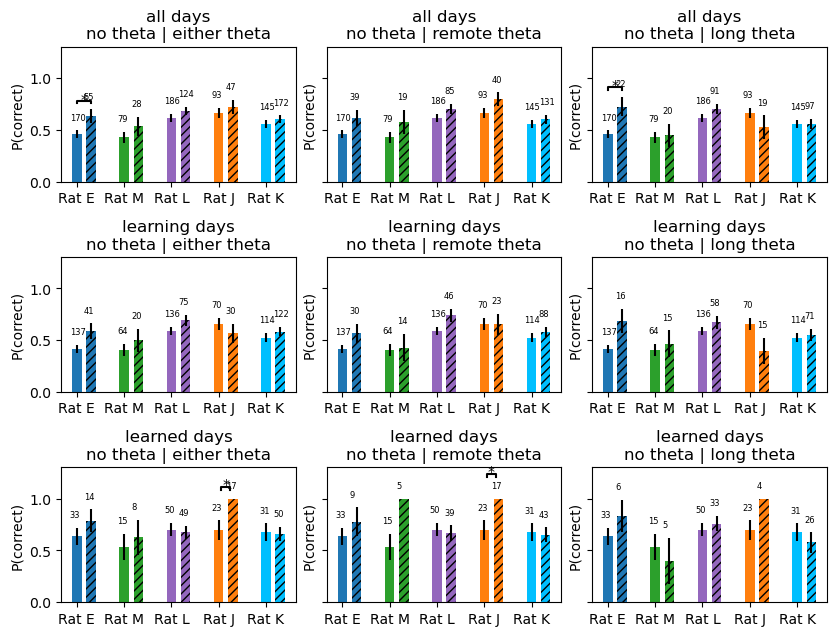

In [10]:
num_of_panels = 3
fig, axes = plt.subplots(3, num_of_panels, figsize=(3 * num_of_panels, 7),sharey = True)

animal_ind = 0
animals = ["eliot","molly","lewis","julio","klein"]
for animal in animals:
    output_path = os.path.join(output_folder,f"{animal}_figure4Fa") #os.join(output_folder,plot_data_filename)
    with open(output_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Data successfully loaded from {output_path}")

    (reward, remote_theta, long_theta, theta, com_num, learning) = (
        loaded_data["reward"],
        loaded_data["remote_theta"], loaded_data["long_theta"], loaded_data["theta"],
        loaded_data["com_num"], loaded_data["learning_flag"])

    for axes_row_ind in [0,1,2]: #all data, learning days, post-learning days
        if axes_row_ind == 0:
            reward_theta = np.array(reward)[np.array(theta) > 0]
            reward_nontheta = np.array(reward)[(1-np.array(theta)) > 0]
            reward_remote_theta = np.array(reward)[np.array(remote_theta) > 0]
            reward_long_theta = np.array(reward)[np.array(long_theta) > 0]
        elif axes_row_ind == 1:
            learning = np.array(learning)
            reward_theta = np.array(reward)[np.logical_and(np.array(theta) > 0, learning)]
            reward_nontheta = np.array(reward)[np.logical_and((1-np.array(theta)) > 0, learning)]
            reward_remote_theta = np.array(reward)[np.logical_and(np.array(remote_theta) > 0, learning)]
            reward_long_theta = np.array(reward)[np.logical_and(np.array(long_theta) > 0, learning)]
        elif axes_row_ind == 2:
            nonlearning = 1 - np.array(learning)
            reward_theta = np.array(reward)[np.logical_and(np.array(theta) > 0, nonlearning)]
            reward_nontheta = np.array(reward)[np.logical_and((1-np.array(theta)) > 0, nonlearning)]
            reward_remote_theta = np.array(reward)[np.logical_and(np.array(remote_theta) > 0, nonlearning)]
            reward_long_theta = np.array(reward)[np.logical_and(np.array(long_theta) > 0, nonlearning)]
            

        # axis 1: nontheta vs theta
        ax = axes[axes_row_ind,0]
        data1, data2 = reward_nontheta, reward_theta
        plot_one_axis(data1, data2, animal_ind, ax, animal)
    
        # axis 2: nontheta vs theta
        ax = axes[axes_row_ind,1]
        data1, data2 = reward_nontheta, reward_remote_theta
        plot_one_axis(data1, data2, animal_ind, ax, animal)

        # axis 3: nontheta vs long theta
        ax = axes[axes_row_ind,2]
        data1, data2 = reward_nontheta, reward_long_theta
        plot_one_axis(data1, data2, animal_ind, ax, animal)
        
    animal_ind += 1

for j in range(3):
    axes_colj = axes[:,j]
    for i in range(3):
        ax = axes[i,j]
        ax.set_xticks(np.arange(len(animals)));
        ax.set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
        ax.set_ylabel("P(correct)")
        #ax.set_xlim([-1,len(animals) + 1]);
        #ax.set_ylim([0.3,0.85]);

        if j == 0:
            title = "no theta | either theta"
        elif j == 1:
            title = "no theta | remote theta"
        elif j == 2:
            title = "no theta | long theta"
        if i == 0:
            title = "all days\n" + title
        elif i == 1:
            title = "learning days\n" + title
        elif i == 2:
            title = "learned days\n" + title
        
        ax.set_title(title)
        
    #axes.set_xlim([-0.2,len(animals)-1 + 0.5])

fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

#plt.savefig(f'extra_correctness_by_theta.pdf',dpi=300,bbox_inches='tight')

### merge all rats

#### a) either remote or local extended

In [58]:
animals = ["eliot","molly","lewis","julio","klein"]

animal_ind = 0

GLM_xy = []
for animal in animals:
    output_path = os.path.join(output_folder,f"{animal}_figure4Fa") #os.join(output_folder,plot_data_filename)
    with open(output_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Data successfully loaded from {output_path}")

    (reward, remote_theta, long_theta, theta, com_num) = (
        loaded_data["reward"], loaded_data["remote_theta"], loaded_data["long_theta"], loaded_data["theta"],loaded_data["com_num"])
    learning = loaded_data["learning_flag"]
    thetaxnonlearning = (1-np.array(learning)) * np.array(loaded_data["theta"])
    remotexlearned = (1-np.array(learning)) * np.array(loaded_data["remote_theta"])
    longxlearned = (1-np.array(learning)) * np.array(loaded_data["long_theta"])

    animal_category = [a == animal for a in animals]
    for ind in range(len(reward)):
        GLM_xy.append(animal_category + [
            com_num[ind],
            theta[ind], long_theta[ind], remote_theta[ind],
            learning[ind],
            thetaxnonlearning[ind],
            longxlearned[ind],
            remotexlearned[ind],
            reward[ind]])

GLM_xy = np.array(GLM_xy)

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/eliot_figure4Fa
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/molly_figure4Fa
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/lewis_figure4Fa
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/julio_figure4Fa
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/klein_figure4Fa


In [60]:
## Model 1: no theta or with theta
feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_xy[:,animal_ind] for animal_ind in range(len(animals))}
feature_dict["com num"] = GLM_xy[:,len(animals)]
feature_dict["theta"] = GLM_xy[:,(len(animals)+1)]

X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y = GLM_xy[:,-1]

"""a) Mixed Linear Effect"""
ols_model = sm.OLS(y,X)
ols_result1 = ols_model.fit()

print("Mixed Linear Effect \n",ols_result1.summary())

"""b) Logistic"""
logistic_model = sm.Logit(y, X)
logistic_result1 = logistic_model.fit()

# 3. View the model summary
print("Mixed Logistics \n",logistic_result1.summary())
 

## Model 2: remote theta or long theta
feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_xy[:,animal_ind] for animal_ind in range(len(animals))}
feature_dict["long theta"] = GLM_xy[:,(len(animals)+2)]
feature_dict["remote theta"] = GLM_xy[:,(len(animals)+3)]
#feature_dict["long theta x learned"] = GLM_xy[:,(len(animals)+6)]
#feature_dict["remote theta x learned"] = GLM_xy[:,(len(animals)+7)]
X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y = GLM_xy[:,-1]

"""a) Mixed Linear Effect"""
ols_model = sm.OLS(y,X)
ols_result2 = ols_model.fit()

print("Mixed Linear Effect \n",ols_result2.summary())

"""b) Logistic"""
logistic_model = sm.Logit(y, X)
logistic_result2 = logistic_model.fit()

# 3. View the model summary
print("Mixed Logistics \n",logistic_result2.summary())



Mixed Linear Effect 
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     5.211
Date:                Fri, 07 Nov 2025   Prob (F-statistic):           2.67e-05
Time:                        22:21:58   Log-Likelihood:                -765.99
No. Observations:                1099   AIC:                             1546.
Df Residuals:                    1092   BIC:                             1581.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4560      0.0

In [61]:
from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars
import statsmodels.api as sm

In [62]:
print("Eliot's example tuple:", GLM_xy[0])
print("Another rat's example tuple:", GLM_xy[-500])
print("Klein's example tuple:", GLM_xy[-1])

Eliot's example tuple: [1 0 0 0 0 1 0 0 0 1 0 0 0 0]
Another rat's example tuple: [0 0 1 0 0 1 1 1 1 0 1 1 1 0]
Klein's example tuple: [0 0 0 0 1 1 0 0 0 0 0 0 0 0]


#### c) plots of coefficients

In [63]:
## if want to plot rat baselines
def model2numbers(ols_result):
    coef_names = ols_result.params.keys()
    coef_est = np.array(ols_result.params)
    pvalues = ols_result.pvalues
    CI = ols_result.conf_int(alpha=0.05)
    #yerr = np.vstack((np.array(CI[0]).reshape((1,-1)), np.array(CI[1]).reshape((1,-1)))) # 2 x coefficients

    return ols_result.params, coef_names, coef_est, pvalues, CI#, yerr

In [68]:
## if do not wish to plot rat baselines
def model2numbers(ols_result):
    coef_names = ols_result.params.keys()
    coef_est = np.array(ols_result.params)
    pvalues = ols_result.pvalues
    CI = ols_result.conf_int(alpha=0.05)
    #yerr = np.vstack((np.array(CI[0]).reshape((1,-1)), np.array(CI[1]).reshape((1,-1)))) # 2 x coefficients

    coef_names_subset_ind = ["Rat" not in name and "cons" not in name for name in coef_names]
    coef_names = np.array(coef_names)[coef_names_subset_ind]
    coef_est = coef_est[coef_names_subset_ind]
    pvalues = pvalues[coef_names_subset_ind]
    CI = CI.loc[coef_names]

    return ols_result.params, coef_names, coef_est, pvalues, CI#, yerr

1.98 0.03
1.98 0.03
Fold change of the effect of remote theta content is 1.411045818162212, with 95% bound: (1.0889506832598679, 1.8284118202604782)


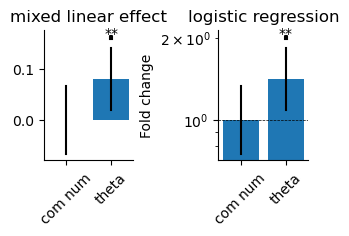

In [71]:
# 4. Create the bar graph using matplotlib

fig, axes = plt.subplots(1,2,figsize=(4, 3))

#### axis 0
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(ols_result1)
axes[0].bar(coef_names, coef_est, error_kw=dict(color='k'))
for coef_name in coef_names:
    axes[0].plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes[0])

axes[0].set_xticks(np.arange(len(coef_names)))
axes[0].set_xticklabels(coef_names, rotation=45)
axes[0].set_title("mixed linear effect")


#### axis 1
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(logistic_result1)
coef_est = np.exp(coef_est)
coef_pd = np.exp(coef_pd)
CI = np.exp(CI)

axes[1].bar(coef_names, coef_est, error_kw=dict(color='k'))
for coef_name in coef_names:
    axes[1].plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes[1], color = 'k')

axes[1].set_xticks(np.arange(len(coef_names)))
axes[1].set_xticklabels(coef_names, rotation=45)
axes[1].set_title("logistic regression")
axes[1].set_ylabel("Fold change")
axes[1].axhline(1,linewidth = 0.5,linestyle='dashed', color = 'k')
axes[1].set_yscale('log') 

theta_point_est = coef_pd.loc["theta"]
theta_CI = CI.loc["theta"]
print(f"Fold change of the effect of remote theta content is {theta_point_est}, with 95% bound: {theta_CI[0],theta_CI[1]}")
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

axes[0].spines[['right', 'top']].set_visible(False)
axes[1].spines[['right', 'top']].set_visible(False)

plt.savefig(f'extra_correctness_by_theta_GLM.pdf',dpi=300,bbox_inches='tight')

1.98 0.03
1.98 0.03
Fold change of the effect of remote theta content is 1.4688193123320492, with 95% bound: (1.096050777291937, 1.9683669926406657)


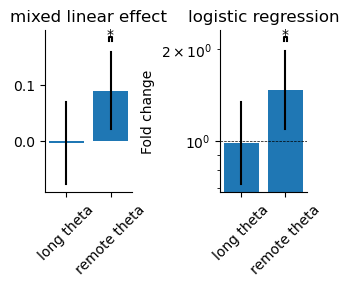

In [72]:
# 4. Create the bar graph using matplotlib

fig, axes = plt.subplots(1,2,figsize=(4, 3.5))

#### axis 0
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(ols_result2)
axes[0].bar(coef_names, coef_est, ecolor='C6')
for coef_name in coef_names:
    axes[0].plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes[0])

axes[0].set_xticks(np.arange(len(coef_names)))
axes[0].set_xticklabels(coef_names, rotation=45)
axes[0].set_title("mixed linear effect")


#### axis 1
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(logistic_result2)
coef_est = np.exp(coef_est)
coef_pd = np.exp(coef_pd)
CI = np.exp(CI)

axes[1].bar(coef_names, coef_est)
for coef_name in coef_names:
    axes[1].plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes[1], color = 'k')

axes[1].set_xticks(np.arange(len(coef_names)))
axes[1].set_xticklabels(coef_names, rotation=45)
axes[1].set_title("logistic regression")
axes[1].set_ylabel("Fold change")
axes[1].axhline(1,linewidth = 0.5,linestyle='dashed', color = 'k')
axes[1].set_yscale('log') 

theta_point_est = coef_pd.loc["remote theta"]
theta_CI = CI.loc["remote theta"]
print(f"Fold change of the effect of remote theta content is {theta_point_est}, with 95% bound: {theta_CI[0],theta_CI[1]}")
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

axes[0].spines[['right', 'top']].set_visible(False)
axes[1].spines[['right', 'top']].set_visible(False)

plt.savefig(f'extra_correctness_by_theta_longtheta_remotetheta.pdf',dpi=300,bbox_inches='tight')